# Project 1: 3D reconstruction from 2D brain scans

In this project, we would like you to investigate image registration.
For this purpose, we will give you a batch of unregistered brain images from our research group.
Your task is to apply the methods from the lecture and transform these images onto each other to obtain a 3D representation of the original brain.
The exercises in this project will guide you through the steps to accomplish this task.

Submit your group's results through ILIAS and make sure all group members are registered. Booking for presentation slots will open in the coming weeks.

## Exercise 1
**Learning goals:** reading and annotating images, estimating 2D transformations, applying 2D transformations

In this exercise, the goal is to familiarize yourself with the data, and manually estimate the transformations between an example pair of images.
After inspecting the images, you will manually select corresponding points in two images and estimate transformation matrices from the selected points.

1. Read some of the provided images (e.g., using `imageio`) and visualize them (e.g., using `matplotlib` or `napari`).
2. Print statistics of the images read, including their type, shapes, and intensity statistics (e.g., min, max, mean, median).
3. For the selected pair of adjacent images, load they keypoints from data/keypoints_ex1 and visualize them. If you want to try your own keypoints, there are several ways to select key points. We recommend familiarizing yourself with [napari](https://napari.org/dev/index.html), which can be used to visualize and annotate images. Alternatively, plotting tools like `matplotlib` typically support [interactive figures](https://matplotlib.org/stable/users/explain/figure/interactive.html), which allow you to extract the coordinates of the pixels under your mouse pointer. **Hint:** Save identified pairs so that you can reuse them later.
4. Using the corresponding points, estimate linear transformations (rigid and affine) to align the images.
5. Align the images using the computed transformations and overlay them (e.g., using the `alpha` parameter in `matplotlib`).

In [1]:
# Basic imports
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
from time import time
import cv2
from PIL import Image

# Student imports
from functions_student import *

In [2]:
# load the images
images = [tiff.imread(name) for name in sorted(glob.glob("data/tiff/*.tif"))]

# plot the images
# TODO: add code here

In [ ]:
# Print type, shapes, and intensity statistics (e.g., min, max, mean, median)
# TODO: add code here

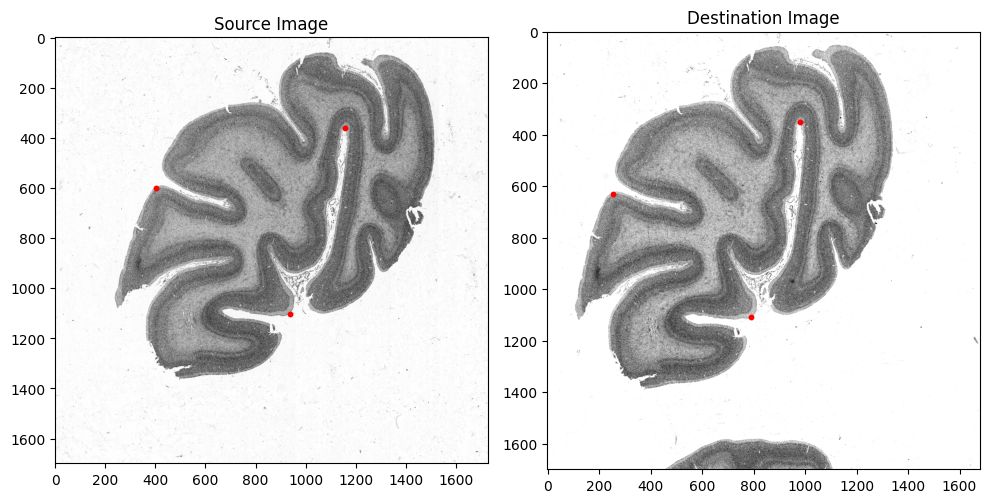

In [3]:
keypoints_src = np.load("data/keypoints_ex1/points_src.npy")
keypoints_dst = np.load("data/keypoints_ex1/points_dst.npy")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(images[0], cmap='gray')
axes[0].scatter(keypoints_src[:, 1], keypoints_src[:, 0], c='r', s=10)
axes[0].set_title("Source Image")
axes[1].imshow(images[1], cmap='gray')
axes[1].scatter(keypoints_dst[:, 1], keypoints_dst[:, 0], c='r', s=10)
axes[1].set_title("Destination Image")
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Implement `get_affine_transformation` and `backwards_mapping` in functions_student.py

affine_transform = get_affine_transformation(points_in=keypoints_src, points_out=keypoints_dst)

# Note: compute the inverse map for backward mapping
inv_transform = ...

output_image = backwards_mapping(image=images[0], output_shape=images[1].shape, transformation=inv_transform)

In [ ]:
# Plotting the results
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(images[0], cmap='gray')
axes[0].set_title("Source Image")

axes[1].imshow(images[1], cmap='gray')
axes[1].set_title("Destination Image")

axes[2].imshow(output_image, cmap='gray')
axes[2].set_title("Transformed Source Image")

axes[3].imshow(images[1], alpha=1., cmap='gray')
axes[3].imshow(output_image, alpha=0.8, cmap='magma')
axes[3].set_title("Images Overlayed")

plt.tight_layout()
plt.show()

## Exercise 2
**Learning goals:** image filtering; downsampling, histogram equalization

In this exercise, you will learn different techniques that are useful for many image analysis projects, including the 3D reconstruction of brain scans.
The goal of this exercise is to implement several image operations yourself.
Using basic `numpy` operations is allowed (e.g., using `np.mean` on one sliding window), but more complex operations must be implemented by yourself (e.g., the logic for a `convolution`).

1. Using at least two images, implement a function that downsamples images using linear interpolation.
2. Using the same images, perform a histogram equalization. Compute the histogram equalization on the downsampled images, then apply it to the original images. In your solution, comment on the advantage of this approach over computing the histogram equalization on the original images only.
3. Implement and apply the following filters on the original and downsampled images, and compare the results 1) mean 2) median 3) Gaussian 4) Sobel filter.
4. Using your Gaussian filter implementation, extent your downsampling implementation to include anti-aliasing.

If you are unsure what the output should look like, check data/artifacts for sample output.
## Read example images

In [ ]:
images = ["data/tiff/B20_0429.tif", "data/tiff/B20_0430.tif"]
images = [np.array(Image.open(img)) for img in images]

for img in images:
    print(img.shape)

## Downsample image

In [ ]:
# TODO: Implement `downsample_bilinear`

In [ ]:
factors = [2, 4, 8, 16]

for f in factors:
    downscaled_images = [downsample_bilinear(img, factor=f) for img in images]
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle(f'Downsampling by a factor of {f}:')
    axes[0, 0].imshow(images[0], cmap='gray')
    axes[0, 0].set_title('Original')
    axes[0, 0].set_ylabel('image 1')
    axes[0, 1].imshow(downscaled_images[0], cmap='gray')
    axes[0, 1].set_title('Downscaled')
    
    axes[1, 0].imshow(images[1], cmap='gray')
    axes[1, 0].set_ylabel('image 2')
    axes[1, 1].imshow(downscaled_images[1], cmap='gray')
    
    plt.tight_layout()
    plt.show()

## Histogram equalization

In [ ]:
img = images[0]

# TODO: Implement `histogram_equalization`
equalized_img = histogram_equalization(img)

# TODO: plot original and equalized images using histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# TODO: plot original and equalized images + histograms with 256 bins
axes[0, 0].imshow(...)

plt.tight_layout()
plt.show()

In [ ]:
# TODO: plot histograms of the downsampled and equalized images
img = downsample_bilinear(images[0], factor=2.3)
img = np.round(img).astype(np.uint8)
equalized_img = histogram_equalization(img)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# TODO: plot original and equalized images + histograms with 256 bins
axes[0, 0].imshow(...)

plt.tight_layout()
plt.show()

In [ ]:
# TODO: advantage of this approach over computing the histogram equalization on the original images only.


## Image filter

In [ ]:
def plot_filtered_images(orig_img, orig_modified, downsampled_img, downsampled_filtered, mode="gaussian", ticks_off=True):
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f"{mode} filter", fontsize=16)
    axes[0, 0].imshow(orig_img, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].imshow(orig_modified, cmap='gray')
    
    axes[1, 0].imshow(downsampled_img, cmap='gray')
    axes[1, 1].imshow(downsampled_filtered, cmap='gray')

    if ticks_off:
        for ax in axes.flat:
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    axes[0, 0].set_title("Input", fontsize=12)
    axes[0, 1].set_title("Filtered", fontsize=12)

    axes[0, 0].set_ylabel("Original", fontsize=12, rotation=90, labelpad=10)
    axes[1, 0].set_ylabel("Downsampled", fontsize=12, rotation=90, labelpad=10)
    
    plt.tight_layout()
    plt.show()

In [ ]:
img = images[0]

# TODO: Implement various filters inside `functions_student.py`
# test gaussian, median, mean, sobel using `filter_wrapper_fn` and check visualizations using `plot_filtered_images`

In [ ]:
# Test filters on original and downsampled image
img = images[0]
downsampled = downsample_bilinear(img, factor=2)

In [ ]:
gaussian_filtered = filter_wrapper_fn(img=img, mode='gaussian', sigma=2.)
downsampled_gaussian_filtered = filter_wrapper_fn(img=downsampled, mode='gaussian')

plot_filtered_images(img, gaussian_filtered, downsampled, downsampled_gaussian_filtered, "gaussian")

In [ ]:
median_filtered = filter_wrapper_fn(img=img, mode='median')
downsampled_median_filtered = filter_wrapper_fn(img=downsampled, mode='median')

plot_filtered_images(img, median_filtered, downsampled, downsampled_median_filtered, "median")

In [ ]:
mean_filtered = filter_wrapper_fn(img=img, mode='mean')
downsampled_mean_filtered = filter_wrapper_fn(img=downsampled, mode='mean')

plot_filtered_images(img, mean_filtered, downsampled, downsampled_mean_filtered, "mean")

In [ ]:
sobel_filtered = filter_wrapper_fn(img=img, mode='sobel')
downsampled_sobel_filtered = filter_wrapper_fn(img=downsampled, mode='sobel')

plot_filtered_images(img, sobel_filtered, downsampled, downsampled_sobel_filtered, "sobel")

## Anti-aliasing

In [ ]:
# TODO apply downsampling (factor 2) to Gaussian-filtered image and plot comparison to original image

## Exercise 3

**Learning goals:** find points of interest, compute key point descriptors, match key point descriptors

Having learnt how to estimate transformations from manually selected key points in exercise 1, you will now learn how to find and match points of interest automatically.

1. Given a pair of adjacent images, use feature detectors from `scikit-image` or `OpenCV` to detect key points in both images (e.g., [SIFT](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.SIFT)).
2. Match the identified points using the matching algorithm described in the lecture.
3. Remove outliers using `RANSAC` (you may use existing implementations).
4. Using your code from exercise 1, calculate transformations between the two images.
5. Apply transformations and inspect the results as in exercise 1.
6. Experiment with filters from exercise 2 to improve results or runtime performance.

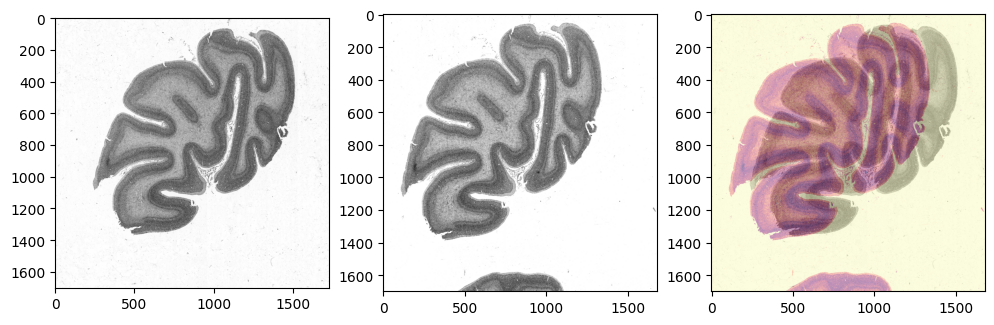

In [4]:
# load the images
img1 = cv2.imread('data/png/B20_0429.png')
img2 = cv2.imread('data/png/B20_0430.png')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Visualization
fig, axes = plt.subplots(1,3, figsize=(12,8))

axes[0].imshow(img1, cmap='gray')
axes[1].imshow(img2, cmap='gray')
axes[2].imshow(img1, cmap='gray', alpha=1.)
axes[2].imshow(img2, cmap='magma', alpha=.5)
plt.show()

In [ ]:
# 1. Feature extraction
# Implement `get_keypoints` in functions_student.py to extract keypoints and descriptors from the images using SIFT or any other method of your choice.
# Note: Use `get_keypoints` to get the keypoints + descriptors. You may use filtering optionally to prune results.
keypoints1, descriptors1 = get_keypoints(...)
keypoints2, descriptors2 = get_keypoints(...)

# Helpful array transform below:
# keypoints1 = np.array([list(keypoints1[i].pt)[::-1] for i in range(len(keypoints1))])
# keypoints2 = np.array([list(keypoints2[i].pt)[::-1] for i in range(len(keypoints2))])

# TODO: Print keypoints and visualize them for both images, use `cv2.drawKeypoints`

In [ ]:
# transform keypoints to numpy array
keypoints1 = np.array([list(keypoints1[i].pt)[::-1] for i in range(len(keypoints1))])
keypoints2 = np.array([list(keypoints2[i].pt)[::-1] for i in range(len(keypoints2))])

## Matching

We implemented a simple distance based matching of the descriptors. A match is valid, when it is significantly better than the second best match, signifiance can be defined by the ratio of distance 1 / distance 2. We also implemented cross-checking, a match is only valid, if it is a significant match for both points.

![An image of the matching process](./exercise3/supplementary/matching.png)

To compute the distances between all descriptors quickly we use scipy.spatial.distance.cdist(). Getting the two smallest distances for each match, we can use numpy.argpartition (this function sorts the array only up to the kth smallest entry. It runs in O(n + k*log(k)).

## RANSAC

Random Sample Consensus is a simple algorithm to predict a robust model on a set with outliers. We sample k points in each iteration and calculate a model based on these points. Next we calculate the number of supporters for this model, this is defined by some cutoff residuum. We return the model with the most support in the group.

One adaptation we used here is to increase k from 3 to 4 which smooths the calculated affine transformations and improves the robustness.

In [ ]:
# 2. Matching and 3. RANSAC

# TODO: implement matching inside `functions_student.py`
matches = matching(descriptors1, descriptors2)

# TODO: implement ransac inside `functions_student.py`
mts_filtered, _ = ransac(keypoints1, keypoints2, matches, percentage_outliers=0.1, probability=0.99, cutoff=20, k=4)


In [ ]:
# Plot remaining points across axes applying filtering checks
num_matches = mts_filtered.shape[0]
cmap = cm.get_cmap('plasma', num_matches)
colors = cmap(np.arange(num_matches))

fig, axes = plt.subplots(1,2, figsize=(12, 8))

axes[0].imshow(img1, cmap='gray')
axes[0].scatter(keypoints1[mts_filtered[:,0], 1], keypoints1[mts_filtered[:,0], 0], c=colors, s=10)
axes[0].set_title("Img1 with keypoints1")
axes[1].imshow(img2, cmap='gray')
axes[1].scatter(keypoints2[mts_filtered[:,1], 1], keypoints2[mts_filtered[:,1], 0], c=colors, s=10)
axes[1].set_title("Img2 with keypoints2")
plt.show()

In [ ]:
# 4. Transform checks
# assuming `mts_filtered` is an (N, 2) array of [idx1, idx2]
src_keypoints = keypoints1[mts_filtered[:, 0]]  # (N, 2): [y, x]
dst_keypoints = keypoints2[mts_filtered[:, 1]]  # (N, 2): [y, x]

# Flip to (x, y) order for skimage.transform
src_pts = np.stack([src_keypoints[:,1], src_keypoints[:,0]], axis=-1)  # (x, y)
dst_pts = np.stack([dst_keypoints[:,1], dst_keypoints[:,0]], axis=-1)  # (x, y)

# Now use with skimage
tform = skt.estimate_transform("affine", src=dst_pts, dst=src_pts)

transformed_img = skt.warp(img2, inverse_map=tform.inverse, output_shape=img1.shape)

fig, axes = plt.subplots(1,2, figsize=(12, 8))

axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].imshow(img2, cmap='magma', alpha=.5, vmin=0, vmax=255)
axes[0].set_title("Before transformation")

axes[1].imshow(transformed_img, cmap='gray')
axes[1].imshow(img1, cmap='magma', alpha=.5, vmin=0, vmax=255)
axes[1].set_title("After transformation")

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title("Source Image")

axes[1].imshow(img2, cmap='gray')
axes[1].set_title("Destination Image")

axes[2].imshow(transformed_img, cmap='gray')
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Calculate the exact affine transform, invert it, map via backwards mapping, and render the alignment overlays
# using the functions from EX 1
affine_transformation = ...
print(affine_transformation)
inv_transform = ...

# Plot Before and after as above

## Exercise 4: Full Reconstruction

**Learning goals:** put together what you learned

In this project, what you learned in the exercises comes together to tackle the 3D reconstruction of 2D brain scans.

1. Use your approach from exercise 3 to compute transformations between any pair of adjacent images.
2. Using one image (e.g., the first one, or the one in the center) as a reference, concatenate and apply the computed transformations to align all images to your reference image.
3. Stack the transformed images into a 3D volume and inspect the result using `napari`.

## Concatenate transformations

First we calculate the affine transformations between all neighbouring pairs. Then, to transform e.g. the second image we first apply $T_2$ then $T_1$ or $T_1 \cdot T_2$.

![Showing the iterative transformation process](./exercise4/supplementary/iterative.gif)

The problem with this approach are error propagations. E.g. an error between the first image pair, will be present in the whole following stack.

In [ ]:
# load the images
images = [tiff.imread(name) for name in sorted(glob.glob("data/tiff/*.tif"))]

# plot the image
for image in images:
    plt.imshow(image, cmap="gray")
    plt.show()


In [ ]:
f_total = time()
n = len(images)
# TODO Pipeline:
# 1. extract all keypoints + descriptors across the images
print(f"Calculating the keypoints")
f = time()

print(f"Done in {time() - f:0.4f} seconds")

In [ ]:
# 2. calculate all the adjacency matches
print(f"Match the descriptors")
f = time()
print(f"Done in {time() - f:0.4f} seconds")

In [ ]:

# 3. determine ransac mapping arrays
print(f"Filter matches with the RANSAC")
f = time()

print(f"Done in {time() - f:0.4f} seconds")

In [ ]:

# 4. compute affine_transformations backwards recursively
print(f"Calculate the affine transformations")
f = time()

print(f"Done in {time() - f:0.4f} seconds")

In [ ]:
# 5. finally backwards warp mapped images onto each other and stack appropriately. Then use helper_plot_fn to verify shifts 
print(f"Applying the affine transformations")
f = time()

print(f"Done in {time() - f:0.4f} seconds")

In [ ]:
# Plot results
for i in range(n-1):
    helper_plot_fn(images[i], images[i+1], transformed_images[i])